In [1]:
import numpy as np
import torch

from src.forecaster import Forecaster
from src.models import LSTMHistoric, LSTMEncoderDecoder
from src.data import DataSource


In [32]:
HISTORIC_COLS = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
FUTURE_COLS   = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
TARGET_COL    = 'target'
HORIZON       = 7
SEQ_LEN       = 30
NODATA_VALUES = [-999]

train_source = DataSource(
    csv='data/data.csv',
    start='1980-01-01',
    end='2004-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
val_source = DataSource(
    csv='data/data.csv',
    start='2005-01-01',
    end='2009-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
test_source = DataSource(
    csv='data/data.csv',
    start='2010-01-01',
    end='2014-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)

In [ ]:
# --- training (commented out — model already trained; loading the saved checkpoint instead) ---
# fc = Forecaster(
#     model=LSTMHistoric,
#     model_config={
#         'LSTM_hidden_size': 28,
#         'LSTM_num_layers': 1,
#         'dropout_rate': 0.0,
#     },
#     name='LSTMHistoric_test',
#     training_datasets=[train_source],
#     validation_datasets=[val_source],
#     historic_cols=HISTORIC_COLS,
#     # future_cols=FUTURE_COLS,
#     target_col=TARGET_COL,
#     forecasting_horizon=HORIZON,
#     historic_input_sequence_length=SEQ_LEN,
#     loss_function='mae',
#     validation_score='nse',
#     validation_logging_criteria=['rmse'],
#     minimize_validation_score=False,
#     save_path='models',
#     batch_size=256,
#     number_of_epochs=50,
#     use_torch_compile=False,
#     save_weights_every_n_epochs=1,
# )

fc = Forecaster.load_model(
    checkpoint_path='models/LSTMHistoric_test/model_LSTMHistoric_test_best.pt',
    model=LSTMHistoric,
    resume=False,
    training_datasets=None,
    device='cpu',
)

print(f'LSTMHistoric parameters: {fc.compute_number_of_parameters()}')


In [ ]:
# fc.fit()  # already trained — see the loading cell above instead


In [ ]:
import matplotlib.pyplot as plt
from src.data.timeseries_dataset import TimeSeriesDataset
from src.data.normalization import _read_1d_df

# predictions via predict() itself (returns a plain numpy array, already denormalized/CPU)
preds = fc.predict(test_source, batch_size=256)
y_pred = preds.squeeze(-1)  # (n_windows, horizon)

# true values + dates: target_col doesn't affect which windows get built (only x_h/x_f NaN
# does), so this dataset covers the exact same windows as predict()'s internal one — it's
# only built here to read off the (source_idx, t) index for alignment, not to run the model
test_ds = TimeSeriesDataset(
    sources=[test_source],
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc.norm_stats,
    target_col=TARGET_COL,
)
test_df = _read_1d_df(test_source)
t_values = np.array([t for _, t in test_ds._index])
y_true = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values])

def lead_dates(lead):
    return test_df.index[t_values + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true.shape[0]} windows over a {y_true.shape[1]}-day horizon on test_source')


In [ ]:
# --- training (commented out — model already trained; loading the saved checkpoint instead) ---
# fc2 = Forecaster(
#     model=LSTMEncoderDecoder,
#     model_config={
#         'LSTM_hidden_size': 16,
#         'LSTM_num_layers': 1,
#         'dropout_rate': 0.0,
#         'encoder_downscale_layer_size': 16,
#     },
#     name='LSTMEncoderDecoder_test',
#     training_datasets=[train_source],
#     validation_datasets=[val_source],
#     historic_cols=HISTORIC_COLS,
#     future_cols=FUTURE_COLS,
#     target_col=TARGET_COL,
#     forecasting_horizon=HORIZON,
#     historic_input_sequence_length=SEQ_LEN,
#     loss_function='mae',
#     validation_score='nse',
#     validation_logging_criteria=['rmse'],
#     minimize_validation_score=False,
#     save_path='models',
#     batch_size=256,
#     number_of_epochs=50,
#     use_torch_compile=False,
#     save_weights_every_n_epochs=1,
# )

fc2 = Forecaster.load_model(
    checkpoint_path='models/LSTMEncoderDecoder_test/model_LSTMEncoderDecoder_test_best.pt',
    model=LSTMEncoderDecoder,
    resume=False,
    training_datasets=None,
    device='cpu',
)

print(f'LSTMEncoderDecoder parameters: {fc2.compute_number_of_parameters()}')


In [ ]:
# fc2.fit()  # already trained — see the loading cell above instead


In [ ]:
preds2 = fc2.predict(test_source, batch_size=256)
y_pred2 = preds2.squeeze(-1)  # (n_windows, horizon)

# same pattern as fc's eval cell above — small TimeSeriesDataset built with fc2's own
# future_cols, purely for window/date alignment via _index, not for running the model
test_ds2 = TimeSeriesDataset(
    sources=[test_source],
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc2.norm_stats,
    target_col=TARGET_COL,
)
t_values2 = np.array([t for _, t in test_ds2._index])
y_true2 = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values2])

def lead_dates2(lead):
    return test_df.index[t_values2 + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true2.shape[0]} windows over a {y_true2.shape[1]}-day horizon on test_source (LSTMEncoderDecoder)')


In [ ]:
# --- training (commented out — model already trained; loading the saved checkpoint instead) ---
# fc3 = Forecaster(
#     model=LSTMHistoric,
#     model_config={
#         'LSTM_hidden_size': 28,
#         'LSTM_num_layers': 1,
#         'dropout_rate': 0.0,
#     },
#     name='LSTMHistoric_dilate_test',
#     training_datasets=[train_source],
#     validation_datasets=[val_source],
#     historic_cols=HISTORIC_COLS,
#     # future_cols=FUTURE_COLS,
#     target_col=TARGET_COL,
#     forecasting_horizon=HORIZON,
#     historic_input_sequence_length=SEQ_LEN,
#     loss_function='dilate',
#     validation_score='nse',
#     validation_logging_criteria=['rmse'],
#     minimize_validation_score=False,
#     save_path='models',
#     batch_size=256,
#     number_of_epochs=50,
#     save_weights_every_n_epochs=1,
# )

fc3 = Forecaster.load_model(
    checkpoint_path='models/LSTMHistoric_dilate_test/model_LSTMHistoric_dilate_test_best.pt',
    model=LSTMHistoric,
    resume=False,
    training_datasets=None,
    device='cpu',
)

print(f'LSTMHistoric (DILATE) parameters: {fc3.compute_number_of_parameters()}')


In [ ]:
# fc3.fit()  # already trained — see the loading cell above instead


In [ ]:
preds3 = fc3.predict(test_source, batch_size=256)
y_pred3 = preds3.squeeze(-1)  # (n_windows, horizon)

# same pattern as fc's eval cell above — small TimeSeriesDataset built with fc3's own
# future_cols, purely for window/date alignment via _index, not for running the model
test_ds3 = TimeSeriesDataset(
    sources=[test_source],
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc3.norm_stats,
    target_col=TARGET_COL,
)
t_values3 = np.array([t for _, t in test_ds3._index])
y_true3 = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values3])

def lead_dates3(lead):
    return test_df.index[t_values3 + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true3.shape[0]} windows over a {y_true3.shape[1]}-day horizon on test_source (LSTMHistoric, DILATE)')


In [ ]:
# --- training (commented out — model already trained; loading the saved checkpoint instead) ---
# fc4 = Forecaster(
#     model=LSTMEncoderDecoder,
#     model_config={
#         'LSTM_hidden_size': 16,
#         'LSTM_num_layers': 1,
#         'dropout_rate': 0.0,
#         'encoder_downscale_layer_size': 16,
#     },
#     name='LSTMEncoderDecoder_dilate_test',
#     training_datasets=[train_source],
#     validation_datasets=[val_source],
#     historic_cols=HISTORIC_COLS,
#     future_cols=FUTURE_COLS,
#     target_col=TARGET_COL,
#     forecasting_horizon=HORIZON,
#     historic_input_sequence_length=SEQ_LEN,
#     loss_function='dilate',
#     validation_score='nse',
#     validation_logging_criteria=['rmse'],
#     minimize_validation_score=False,
#     save_path='models',
#     batch_size=256,
#     number_of_epochs=50,
#     use_torch_compile=False,
#     save_weights_every_n_epochs=1,
# )

fc4 = Forecaster.load_model(
    checkpoint_path='models/LSTMEncoderDecoder_dilate_test/model_LSTMEncoderDecoder_dilate_test_best.pt',
    model=LSTMEncoderDecoder,
    resume=False,
    training_datasets=None,
    device='cpu',
)

print(f'LSTMEncoderDecoder (DILATE) parameters: {fc4.compute_number_of_parameters()}')


In [ ]:
# fc4.fit()  # already trained — see the loading cell above instead


In [ ]:
preds4 = fc4.predict(test_source, batch_size=256)
y_pred4 = preds4.squeeze(-1)  # (n_windows, horizon)

# same pattern as fc's eval cell above — small TimeSeriesDataset built with fc4's own
# future_cols, purely for window/date alignment via _index, not for running the model
test_ds4 = TimeSeriesDataset(
    sources=[test_source],
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    norm_stats=fc4.norm_stats,
    target_col=TARGET_COL,
)
t_values4 = np.array([t for _, t in test_ds4._index])
y_true4 = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values4])

def lead_dates4(lead):
    return test_df.index[t_values4 + SEQ_LEN + (lead - 1)]

print(f'Evaluated {y_true4.shape[0]} windows over a {y_true4.shape[1]}-day horizon on test_source (LSTMEncoderDecoder, DILATE)')


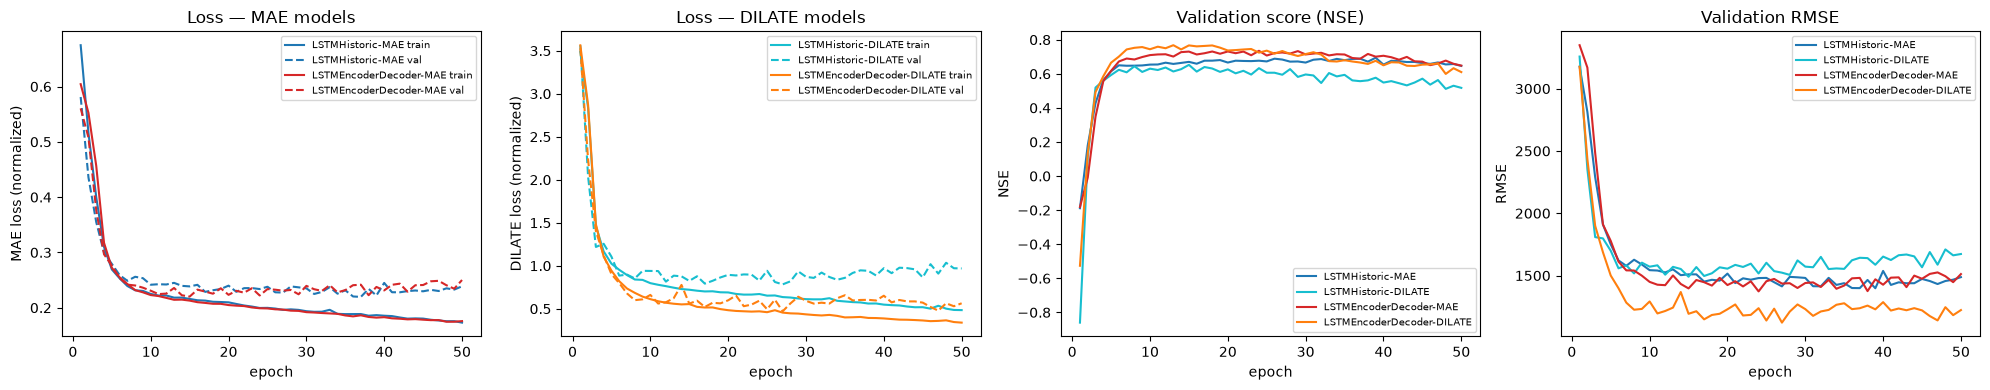

In [39]:
models = [
    ('LSTMHistoric-MAE', fc, 'tab:blue', 'mae'),
    ('LSTMHistoric-DILATE', fc3, 'tab:cyan', 'dilate'),
    ('LSTMEncoderDecoder-MAE', fc2, 'tab:red', 'mae'),
    ('LSTMEncoderDecoder-DILATE', fc4, 'tab:orange', 'dilate'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# loss is split by loss function — MAE-loss and DILATE-loss values live on different
# scales and aren't comparable on a shared axis
for label, m, color, loss_type in models:
    ep = np.arange(1, len(m.loss_log) + 1)
    ax = axes[0] if loss_type == 'mae' else axes[1]
    ax.plot(ep, m.loss_log, color=color, label=f'{label} train')
    ax.plot(ep, m.val_log_aggregated['mean']['loss'], color=color, linestyle='--', label=f'{label} val')
    axes[2].plot(ep, m.val_log_aggregated['mean']['val_score'], color=color, label=label)
    axes[3].plot(ep, m.val_log_aggregated['mean']['RMSE'], color=color, label=label)

axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MAE loss (normalized)')
axes[0].set_title('Loss — MAE models')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('epoch')
axes[1].set_ylabel('DILATE loss (normalized)')
axes[1].set_title('Loss — DILATE models')
axes[1].legend(fontsize=7)

axes[2].set_xlabel('epoch')
axes[2].set_ylabel('NSE')
axes[2].set_title('Validation score (NSE)')
axes[2].legend(fontsize=7)

axes[3].set_xlabel('epoch')
axes[3].set_ylabel('RMSE')
axes[3].set_title('Validation RMSE')
axes[3].legend(fontsize=7)

plt.tight_layout()
plt.show()

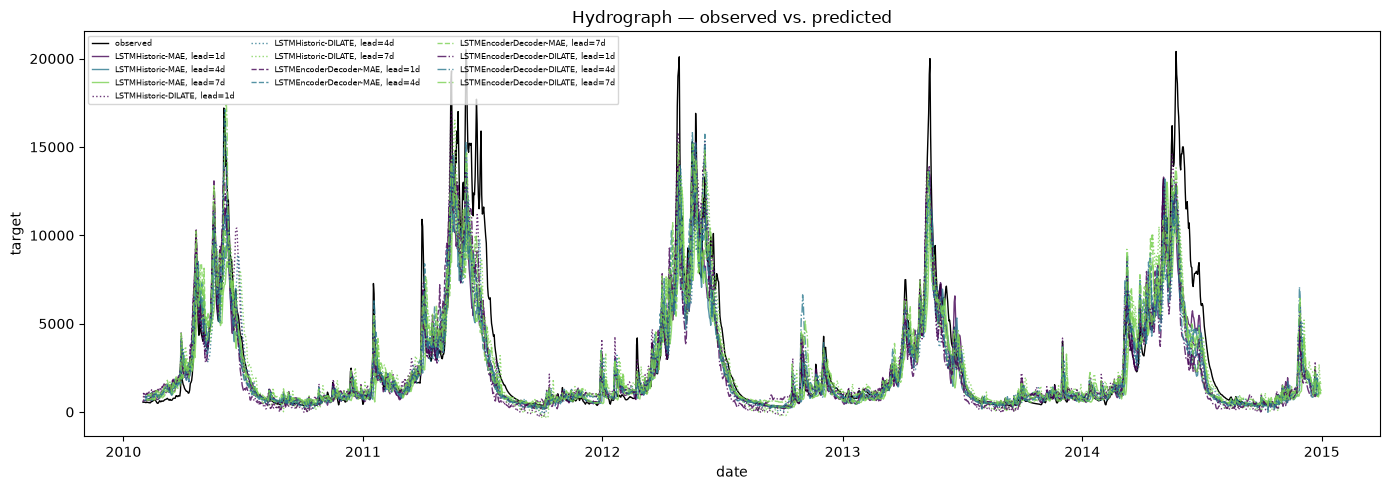

In [40]:
LEADS_TO_SHOW = [1, 4, 7]

# color encodes lead time, linestyle encodes model (architecture + loss)
model_preds = [
    ('LSTMHistoric-MAE', y_pred, t_values, '-'),
    ('LSTMHistoric-DILATE', y_pred3, t_values3, ':'),
    ('LSTMEncoderDecoder-MAE', y_pred2, t_values2, '--'),
    ('LSTMEncoderDecoder-DILATE', y_pred4, t_values4, '-.'),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lead_dates(1), y_true[:, 0], color='black', lw=1, label='observed')
colors = plt.cm.viridis(np.linspace(0, 0.8, len(LEADS_TO_SHOW)))
for label, y_p, t_vals, ls in model_preds:
    for lead, c in zip(LEADS_TO_SHOW, colors):
        dates = test_df.index[t_vals + SEQ_LEN + (lead - 1)]
        ax.plot(dates, y_p[:, lead - 1], color=c, lw=1, alpha=0.8, linestyle=ls, label=f'{label}, lead={lead}d')
ax.set_xlabel('date')
ax.set_ylabel(TARGET_COL)
ax.set_title('Hydrograph — observed vs. predicted')
ax.legend(ncol=3, fontsize=6)

plt.tight_layout()
plt.show()

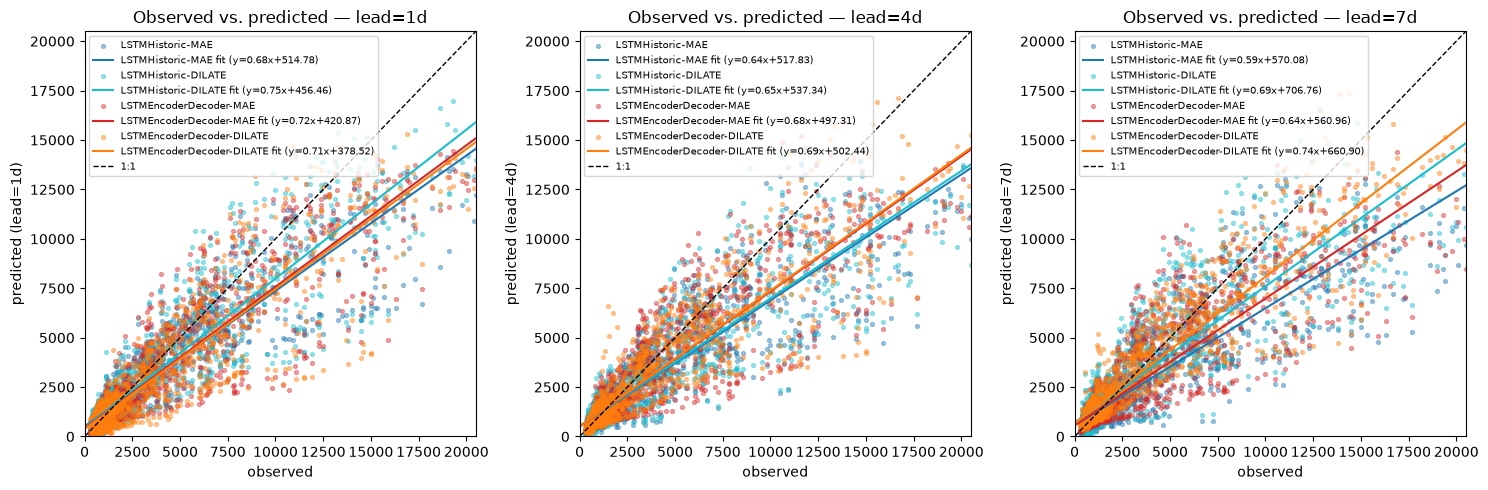

In [41]:
LEADS_TO_SHOW = [1, 4, 7]

model_preds = [
    ('LSTMHistoric-MAE', y_true, y_pred, 'tab:blue'),
    ('LSTMHistoric-DILATE', y_true3, y_pred3, 'tab:cyan'),
    ('LSTMEncoderDecoder-MAE', y_true2, y_pred2, 'tab:red'),
    ('LSTMEncoderDecoder-DILATE', y_true4, y_pred4, 'tab:orange'),
]

fig, axes = plt.subplots(1, len(LEADS_TO_SHOW), figsize=(5 * len(LEADS_TO_SHOW), 5))
lims = [0, np.nanmax([np.nanmax(yt) for _, yt, _, _ in model_preds] + [np.nanmax(yp) for _, _, yp, _ in model_preds])]

for ax, lead in zip(axes, LEADS_TO_SHOW):
    for label, yt, yp, color in model_preds:
        x = yt[:, lead - 1]
        y = yp[:, lead - 1]
        ax.scatter(x, y, s=8, alpha=0.4, color=color, label=label)

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() > 1:
            slope, intercept = np.polyfit(x[mask], y[mask], 1)
            xs = np.array(lims)
            ax.plot(xs, slope * xs + intercept, color=color, lw=1.5,
                    label=f'{label} fit (y={slope:.2f}x+{intercept:.2f})')

    ax.plot(lims, lims, color='black', lw=1, linestyle='--', label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('observed')
    ax.set_ylabel(f'predicted (lead={lead}d)')
    ax.set_title(f'Observed vs. predicted — lead={lead}d')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

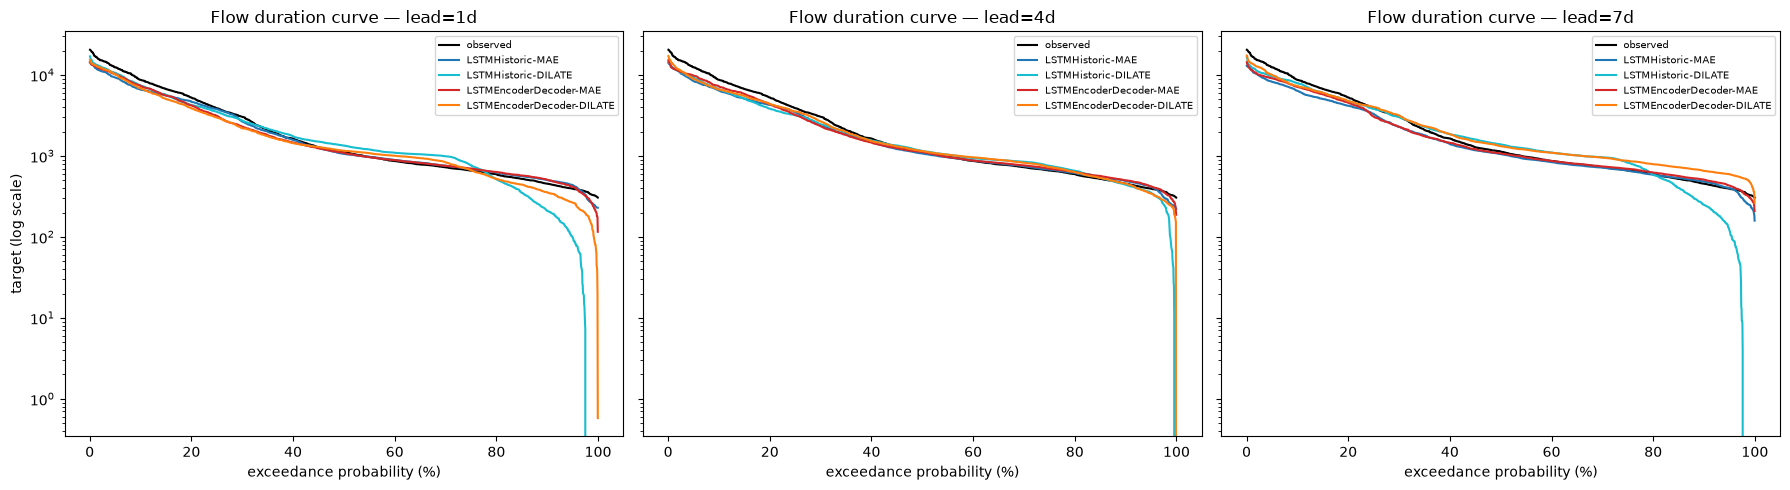

In [42]:
LEADS_TO_SHOW = [1, 4, 7]

def flow_duration_curve(values):
    values = values[~np.isnan(values)]
    sorted_vals = np.sort(values)[::-1]
    exceedance = np.arange(1, len(sorted_vals) + 1) / (len(sorted_vals) + 1) * 100
    return exceedance, sorted_vals

model_preds = [
    ('LSTMHistoric-MAE', y_pred, 'tab:blue'),
    ('LSTMHistoric-DILATE', y_pred3, 'tab:cyan'),
    ('LSTMEncoderDecoder-MAE', y_pred2, 'tab:red'),
    ('LSTMEncoderDecoder-DILATE', y_pred4, 'tab:orange'),
]

fig, axes = plt.subplots(1, len(LEADS_TO_SHOW), figsize=(6 * len(LEADS_TO_SHOW), 5), sharey=True)

for ax, lead in zip(axes, LEADS_TO_SHOW):
    exc_obs, sorted_obs = flow_duration_curve(y_true[:, lead - 1])
    ax.plot(exc_obs, sorted_obs, label='observed', color='black')
    for label, yp, color in model_preds:
        exc_pred, sorted_pred = flow_duration_curve(yp[:, lead - 1])
        ax.plot(exc_pred, sorted_pred, label=label, color=color)
    ax.set_yscale('log')
    ax.set_xlabel('exceedance probability (%)')
    ax.set_title(f'Flow duration curve — lead={lead}d')
    ax.legend(fontsize=7)

axes[0].set_ylabel(f'{TARGET_COL} (log scale)')
plt.tight_layout()
plt.show()

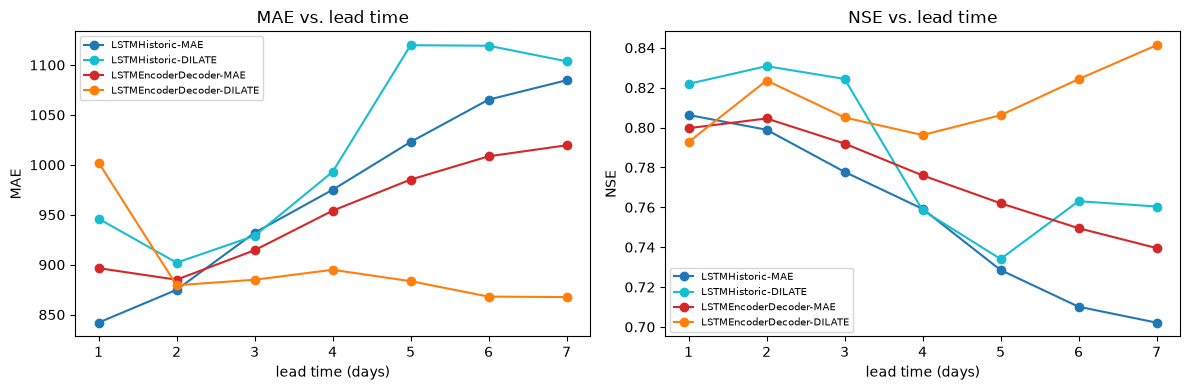

In [43]:
from src.utils.scores_and_losses import NSE

_nse_metric = NSE()

def nse(obs, pred):
    mask = ~np.isnan(obs) & ~np.isnan(pred)
    return _nse_metric(torch.tensor(pred[mask]), torch.tensor(obs[mask])).item()

leads = np.arange(1, HORIZON + 1)
model_preds = [
    ('LSTMHistoric-MAE', y_true, y_pred, 'tab:blue'),
    ('LSTMHistoric-DILATE', y_true3, y_pred3, 'tab:cyan'),
    ('LSTMEncoderDecoder-MAE', y_true2, y_pred2, 'tab:red'),
    ('LSTMEncoderDecoder-DILATE', y_true4, y_pred4, 'tab:orange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, yt, yp, color in model_preds:
    mae_per_lead = [np.nanmean(np.abs(yt[:, i] - yp[:, i])) for i in range(HORIZON)]
    nse_per_lead = [nse(yt[:, i], yp[:, i]) for i in range(HORIZON)]
    axes[0].plot(leads, mae_per_lead, marker='o', color=color, label=label)
    axes[1].plot(leads, nse_per_lead, marker='o', color=color, label=label)

axes[0].set_xlabel('lead time (days)')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs. lead time')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('lead time (days)')
axes[1].set_ylabel('NSE')
axes[1].set_title('NSE vs. lead time')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()